In [ ]:
import os
os.listdir('/content/dataset/Dataset')

['test',
 'README.roboflow.txt',
 'README.dataset.txt',
 'README.md',
 'train',
 'valid']

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip '/content/drive/MyDrive/Dataset.zip' -d /content/dataset

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: /content/dataset/Dataset/train/labels/DTR (8635).txt  
  inflating: /content/dataset/Dataset/train/labels/DTR (8636).txt  
  inflating: /content/dataset/Dataset/train/labels/DTR (8637).txt  
  inflating: /content/dataset/Dataset/train/labels/DTR (8638).txt  
  inflating: /content/dataset/Dataset/train/labels/DTR (8639).txt  
  inflating: /content/dataset/Dataset/train/labels/DTR (864).txt  
  inflating: /content/dataset/Dataset/train/labels/DTR (8640).txt  
  inflating: /content/dataset/Dataset/train/labels/DTR (8641).txt  
  inflating: /content/dataset/Dataset/train/labels/DTR (8642).txt  
  inflating: /content/dataset/Dataset/train/labels/DTR (8643).txt  
  inflating: /content/dataset/Dataset/train/labels/DTR (8644).txt  
  inflating: /content/dataset/Dataset/train/labels/DTR (8645).txt  
  inflating: /content/dataset/Dataset/train/labels/DTR (8646).txt  
  inflating: /content/dataset/Dataset/train/label

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# путь к папке с картинками
path_train = '/content/dataset/Dataset/train/images'
path_valid = '/content/dataset/Dataset/valid/images'
path_test = '/content/dataset/Dataset/test/images'

# 1. Определяем параметры
IMG_SIZE = (224, 224) # Размер, к которому приведем все фото
BATCH_SIZE = 48        # Сколько картинок сеть видит за один шаг

# 2. Настраиваем предобработку

test_datagen = ImageDataGenerator(rescale=1./255)

# Настраиваем генератор с аугментацией для тренировочных данных
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Нормализация (обязательно)
    rotation_range=20,       # Поворот на 20 градусов
    width_shift_range=0.2,   # Сдвиг по горизонтали
    height_shift_range=0.2,  # Сдвиг по вертикали
    shear_range = 0.3,
    horizontal_flip=True,    # Отражение слева направо
    fill_mode='nearest'      # Чем заполнять пустые места при поворотах
)

# 3. Загружаем данные из папок
# Предполагаем, что внутри Train/ у тебя есть подпапки Bird и Drone
train_generator = train_datagen.flow_from_directory(
    path_train, # путь к папке Train
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'      # У нас 2 класса, поэтому бинарная классификация
)

val_generator = test_datagen.flow_from_directory(
    path_valid,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    path_test,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False            # Для теста перемешивание не нужно
)

Found 18323 images belonging to 2 classes.
Found 1740 images belonging to 2 classes.
Found 889 images belonging to 2 classes.


### Создание модели

In [45]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# 1. Определяем вход
inputs = Input(shape=(*IMG_SIZE, 3))
SIZE_FILTRE = (5, 5)
# Первый сверточный блок
x = Conv2D(16, SIZE_FILTRE, activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

# Второй сверточный блок
x = Conv2D(32, SIZE_FILTRE, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

# третий сверточный слой
x = Conv2D(64, SIZE_FILTRE, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
# x = Conv2D(64, SIZE_FILTRE), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)

# x = Conv2D(128, SIZE_FILTRE, padding='same', activation='relu')(x)
# x = BatchNormalization()(x)
# x = MaxPooling2D((2, 2))(x)

# 3. Плоский вектор и полносвязные слои
x = Flatten()(x)
# x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.4)(x)
# x = Dense(128, activation='relu')(x)
# x = Dropout(0.4)(x)

# 4. Выходной слой
outputs = Dense(1, activation='sigmoid')(x)

# 5. Сборка модели: указываем, где начало и где конец
model = Model(inputs=inputs, outputs=outputs)

# Компиляция остается такой же
model.compile(
    optimizer='adam',                # «Умный» алгоритм обновления весов
    loss='binary_crossentropy',      # Функция потерь для 2-х классов
    metrics=['accuracy']             # Мы хотим видеть точность в %
)

model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 16)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 32)   │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,277,153 (12.50 MB)

 Trainable params: 3,276,929 (12.50 MB)

 Non-trainable params: 224 (896.00 B)

### второй вариант модели

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model

inputs = Input(shape=(*IMG_SIZE, 3))

def conv_block(filters, x):
    x = Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    return x

x = conv_block(32, inputs)
x = conv_block(64, x)
x = conv_block(128, x)
x = conv_block(256, x) # Добавили глубины для деталей
x = conv_block(512, x)

x = GlobalAveragePooling2D()(x) # Вместо Flatten для борьбы с переобучением
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)


# Компиляция остается такой же
model.compile(
    optimizer='adam',                # «Умный» алгоритм обновления весов
    loss='binary_crossentropy',      # Функция потерь для 2-х классов
    metrics=['accuracy']             # Мы хотим видеть точность в %
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,605,441 (6.12 MB)

 Trainable params: 1,603,457 (6.12 MB)

 Non-trainable params: 1,984 (7.75 KB)

### Обучение модели

In [49]:
history = model.fit(
    train_generator,                 # Твои обучающие данные
    epochs=3,                       # Сколько раз сеть «прочитает» весь учебник
    validation_data=val_generator    # Проверка на данных, которые сеть не видела
)

Epoch 1/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 268s 702ms/step - accuracy: 0.9804 - loss: 0.0599 - val_accuracy: 0.6172 - val_loss: 3.6856
Epoch 2/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 261s 683ms/step - accuracy: 0.9877 - loss: 0.0386 - val_accuracy: 0.4029 - val_loss: 8.9883
Epoch 3/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 261s 681ms/step - accuracy: 0.9882 - loss: 0.0367 - val_accuracy: 0.6431 - val_loss: 1.0928


### Сохранение попыток

In [50]:
# Если в переменной model сейчас та самая удачная сеть:
model.save('model_cnn.keras')

### Оценка качества обучения

In [7]:
# Создаем пустой список для всех запусков
all_experiments = []

In [52]:
# Используем функцию из прошлого шага (evaluate_model_full)
model_metrics, model_cm = evaluate_model_full(model, test_generator, "My_model")

# Добавляем в наш общий массив сравнения
all_experiments.append({
    'name': 'My_model',
    'metrics': model_metrics,
    'history': history.history
})


=== Анализ модели: My_model ===
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step


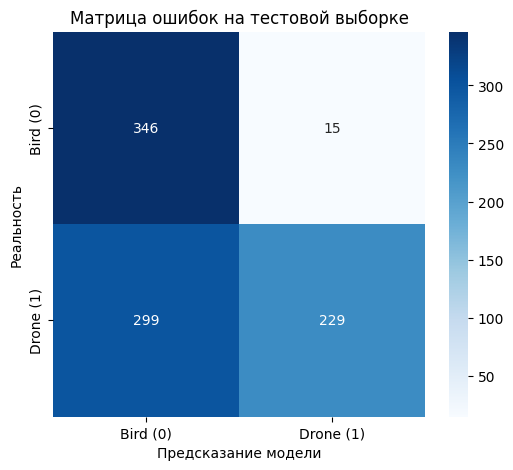

              precision    recall  f1-score   support

        Bird       0.54      0.96      0.69       361
       Drone       0.94      0.43      0.59       528

    accuracy                           0.65       889
   macro avg       0.74      0.70      0.64       889
weighted avg       0.78      0.65      0.63       889



In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Сбрасываем индекс генератора, чтобы файлы шли по порядку
test_generator.reset()

# 2. Получаем предсказания (вероятности)
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 3. Получаем реальные метки
y_true = test_generator.classes

# 4. Строим матрицу
cm = confusion_matrix(y_true, y_pred)

# Визуализация
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bird (0)', 'Drone (1)'],
            yticklabels=['Bird (0)', 'Drone (1)'])
plt.title('Матрица ошибок на тестовой выборке')
plt.ylabel('Реальность')
plt.xlabel('Предсказание модели')
plt.show()

# 5. Подробный отчет по метрикам
print(classification_report(y_true, y_pred, target_names=['Bird', 'Drone']))

### не придумал

In [ ]:
# test_generator мы создавали на Этапе 2
# Важно: shuffle=False должен быть установлен в генераторе для корректных отчетов
results = model.evaluate(test_generator)
print(f"Тестовые потери (Loss): {results[0]}")
print(f"Тестовая точность (Accuracy): {results[1] * 100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step - accuracy: 0.5939 - loss: 3.6316
Тестовые потери (Loss): 3.6316263675689697
Тестовая точность (Accuracy): 59.39%


In [ ]:
# Важно: в генераторе shuffle должен быть False, иначе ты не сопоставишь
# предсказание с реальным именем файла!
test_generator.reset()

# Получаем вероятности (массив чисел от 0 до 1)
predictions = model.predict(test_generator, steps=len(test_generator), verbose=1)

# Превращаем вероятности в четкие классы: 0 (Bird) или 1 (Drone)
# Граница 0.5 — стандарт. Все что выше 0.5 -> Дрон.
predicted_classes = (predictions > 0.5).astype(int).flatten()

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step


In [ ]:
import pandas as pd

# Получаем реальные метки и имена файлов
true_classes = test_generator.classes
filenames = test_generator.filenames

# Создаем таблицу для анализа
results_df = pd.DataFrame({
    "Filename": filenames,
    "Actual": true_classes,
    "Predicted": predicted_classes,
    "Probability": predictions.flatten()
})

# Выводим только ошибки
errors = results_df[results_df['Actual'] != results_df['Predicted']]
print(f"Количество ошибок: {len(errors)} из {len(filenames)}")
print(errors.sample(20)) # Посмотрим на первые 10 ошибок

Количество ошибок: 361 из 889
               Filename  Actual  Predicted   Probability
799  Drone/DT (494).jpg       1          0  1.703344e-05
753  Drone/DT (452).jpg       1          0  1.322082e-05
822  Drone/DT (514).jpg       1          0  2.874468e-03
742  Drone/DT (442).jpg       1          0  3.330189e-06
676  Drone/DT (383).jpg       1          0  9.423088e-03
482  Drone/DT (208).jpg       1          0  1.250771e-05
629  Drone/DT (340).jpg       1          0  1.839582e-04
670  Drone/DT (378).jpg       1          0  7.385496e-04
675  Drone/DT (382).jpg       1          0  9.485518e-05
601  Drone/DT (315).jpg       1          0  1.280896e-05
744  Drone/DT (444).jpg       1          0  9.234068e-07
515  Drone/DT (238).jpg       1          0  2.287169e-05
567  Drone/DT (285).jpg       1          0  2.597164e-05
659  Drone/DT (368).jpg       1          0  1.629390e-04
807  Drone/DT (500).jpg       1          0  5.201017e-05
669  Drone/DT (377).jpg       1          0  2.773220e-04
6

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import pandas as pd

# 1. Словарь моделей для тестирования
# Примечание: Мы используем weights='imagenet' - это и есть предобученные веса
models_to_test = {
    'ResNet50': tf.keras.applications.ResNet50,
    'MobileNetV2': tf.keras.applications.MobileNetV2,
    'EfficientNetB0': tf.keras.applications.EfficientNetB0
}

results = {} # Сюда будем сохранять итоги

def train_pretrained(model_name, model_func):
    print(f"\n--- Начинаем обучение модели: {model_name} ---")

    # Загружаем базу без "головы" (include_top=False)
    base_model = model_func(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))

    # ЗАМОРАЖИВАЕМ ВЕСА (чтобы не испортить то, что нейросеть уже знает)
    base_model.trainable = False

    # Собираем
    inputs = Input(shape=(*IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x) # Превращаем карту признаков в вектор
    x = Dropout(0.2)(x)             # Защита от переобучения
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Обучаем (3-5 эпох хватит для Transfer Learning)
    history = model.fit(
        train_generator,
        epochs=3,
        validation_data=val_generator,
        verbose=1
    )
    return history

# 2. Цикл обучения всех моделей
for name, func in models_to_test.items():
    history = train_pretrained(name, func)
    results[name] = history.history

# Добавим сюда же результаты твоей собственной сети (если сохранились)
# results['My_CNN'] = history_my_cnn.history


--- Начинаем обучение модели: ResNet50 ---
Epoch 1/3
287/287 ━━━━━━━━━━━━━━━━━━━━ 185s 600ms/step - accuracy: 0.6109 - loss: 0.6475 - val_accuracy: 0.5971 - val_loss: 0.6725
Epoch 2/3
287/287 ━━━━━━━━━━━━━━━━━━━━ 163s 567ms/step - accuracy: 0.6645 - loss: 0.6027 - val_accuracy: 0.6270 - val_loss: 0.6700
Epoch 3/3
287/287 ━━━━━━━━━━━━━━━━━━━━ 167s 581ms/step - accuracy: 0.6998 - loss: 0.5805 - val_accuracy: 0.6218 - val_loss: 0.6585

--- Начинаем обучение модели: MobileNetV2 ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/3
287/287 ━━━━━━━━━━━━━━━━━━━━ 211s 668ms/step - accuracy: 0.9506 - loss: 0.1300 - val_accuracy: 0.8293 - val_loss: 0.4303
Epoch 2/3
287/287 ━━━━━━━━━━━━━━━━━━━━ 160s 558ms/step - accuracy: 0.9873 - loss: 0.0413 - val_accuracy: 0.8161 - val_loss: 0.4879
Epoch 3/3
112/287 ━━━━━━━━━━━━━━━━━━━━ 1:37 556ms/step - accuracy: 0.9917 - loss: 0.0291

KeyboardInterrupt: 

### Предобученные модели

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

def evaluate_model_full(model, generator, model_name):
    print(f"\n=== Анализ модели: {model_name} ===")

    # Получаем предсказания
    generator.reset()
    y_pred_probs = model.predict(generator)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    y_true = generator.classes

    # 1. Метрики (Accuracy, Recall, F1)
    report = classification_report(y_true, y_pred, target_names=['Bird', 'Drone'], output_dict=True)

    # 2. Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)

    # Собираем основные данные в словарь для итогового сравнения
    metrics_summary = {
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'Bird_F1': report['Bird']['f1-score'],
        'Drone_F1': report['Drone']['f1-score'],
        'Recall_Drone': report['Drone']['recall'] # Важно для безопасности
    }

    return metrics_summary, cm

#### С заморозкой весов

##### **ResNet50**

###### Адаптация и сборка

In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# Загружаем ResNet50 без верхних слоев (include_top=False)
# weights='imagenet' - это те самые предобученные веса
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# ЗАМОРАЖИВАЕМ веса (Пункт 6 - первая часть)
base_model_resnet.trainable = False

# Собираем модель (Functional API)
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x) # Вместо Flatten, чтобы не переобучаться
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_resnet = Model(inputs=base_model_resnet.input, outputs=outputs)

# Компилируем
model_resnet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


###### Обучение

In [12]:
print("Начинаем обучение ResNet50 (Frozen)...")

history_resnet_frozen = model_resnet.fit(
    train_generator,
    epochs=3, # Для замороженной базы 3-5 эпох обычно за глаза
    validation_data=val_generator,
    verbose=1
)

# Сразу сохраняем, чтобы не потерять (как мы обсуждали)
model_resnet.save('resnet50_frozen.keras')

Начинаем обучение ResNet50 (Frozen)...
Epoch 1/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 301s 753ms/step - accuracy: 0.6961 - loss: 0.5677 - val_accuracy: 0.6402 - val_loss: 0.6412
Epoch 2/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 277s 726ms/step - accuracy: 0.7753 - loss: 0.4695 - val_accuracy: 0.6983 - val_loss: 0.5803
Epoch 3/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 273s 714ms/step - accuracy: 0.8159 - loss: 0.4088 - val_accuracy: 0.7109 - val_loss: 0.5203


###### Оценка качества

In [13]:
# Используем функцию из прошлого шага (evaluate_model_full)
resnet_metrics, resnet_cm = evaluate_model_full(model_resnet, test_generator, "ResNet50_Frozen")

# Добавляем в наш общий массив сравнения
all_experiments.append({
    'name': 'ResNet50_Frozen',
    'metrics': resnet_metrics,
    'history': history_resnet_frozen.history
})


=== Анализ модели: ResNet50_Frozen ===
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 483ms/step


In [14]:
resnet_cm

array([[318,  43],
       [222, 306]])

##### **MobileNetV2**

###### Адаптация и сборка

In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# Загружаем MobileNetV2 без верхних слоев (include_top=False)
# weights='imagenet' - это те самые предобученные веса
base_model_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# ЗАМОРАЖИВАЕМ веса (Пункт 6 - первая часть)
base_model_mobilenet.trainable = False

# Собираем модель (Functional API)
x = base_model_mobilenet.output
x = GlobalAveragePooling2D()(x) # Вместо Flatten, чтобы не переобучаться
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_mobilenet = Model(inputs=base_model_mobilenet.input, outputs=outputs)

# Компилируем
model_mobilenet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


###### Обучение

In [16]:
print("Начинаем обучение MobileNetV2 (Frozen)...")

history_mobilenet_frozen = model_mobilenet.fit(
    train_generator,
    epochs=3, # Для замороженной базы 3-5 эпох обычно за глаза
    validation_data=val_generator,
    verbose=1
)

# Сразу сохраняем, чтобы не потерять (как мы обсуждали)
model_mobilenet.save('mobilenetv2_frozen.keras')

Начинаем обучение MobileNetV2 (Frozen)...
Epoch 1/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 314s 769ms/step - accuracy: 0.9824 - loss: 0.0449 - val_accuracy: 0.9621 - val_loss: 0.1761
Epoch 2/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 271s 709ms/step - accuracy: 0.9919 - loss: 0.0221 - val_accuracy: 0.9661 - val_loss: 0.1322
Epoch 3/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 313s 819ms/step - accuracy: 0.9949 - loss: 0.0141 - val_accuracy: 0.9598 - val_loss: 0.1668


###### Оценка качества

In [17]:
# Используем функцию из прошлого шага (evaluate_model_full)
mobilenet_metrics, mobilenet_cm = evaluate_model_full(model_mobilenet, test_generator, "MobileNetV2_Frozen")

# Добавляем в наш общий массив сравнения
all_experiments.append({
    'name': 'MobileNetV2_Frozen',
    'metrics': mobilenet_metrics,
    'history': history_mobilenet_frozen.history
})


=== Анализ модели: MobileNetV2_Frozen ===
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 837ms/step


In [18]:
mobilenet_cm

array([[361,   0],
       [ 35, 493]])

##### **ShuffleNet**

###### Адаптация и сборка

In [30]:
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Создаем базу с весами imagenet
base_model_shuff = EfficientNetB2(input_shape=(*IMG_SIZE, 3), weights='imagenet', include_top=False)

# ЗАМОРАЖИВАЕМ веса (Пункт 6 - первая часть)
base_model_shuff.trainable = False

# Собираем модель (Functional API)
x = base_model_shuff.output
x = GlobalAveragePooling2D()(x) # Вместо Flatten, чтобы не переобучаться
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_shuff = Model(inputs=base_model_shuff.input, outputs=outputs)

# Компилируем
model_shuff.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


###### Обучение

In [31]:
print("Начинаем обучение ShuffleNet (Frozen)...")

history_shuff_frozen = model_shuff.fit(
    train_generator,
    epochs=3, # Для замороженной базы 3-5 эпох обычно за глаза
    validation_data=val_generator,
    verbose=1
)

# Сразу сохраняем, чтобы не потерять (как мы обсуждали)
model_shuff.save('shufflenet_frozen.keras')

Начинаем обучение ShuffleNet (Frozen)...
Epoch 1/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 355s 826ms/step - accuracy: 0.5921 - loss: 0.6760 - val_accuracy: 0.5971 - val_loss: 0.6747
Epoch 2/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 287s 753ms/step - accuracy: 0.5968 - loss: 0.6707 - val_accuracy: 0.5971 - val_loss: 0.6753
Epoch 3/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 273s 714ms/step - accuracy: 0.5967 - loss: 0.6693 - val_accuracy: 0.5971 - val_loss: 0.6752


###### Оценка качества

In [32]:
# Используем функцию из прошлого шага (evaluate_model_full)
shuff_metrics, shuff_cm = evaluate_model_full(model_shuff, test_generator, "ShuffleNet_Frozen")

# Добавляем в наш общий массив сравнения
all_experiments.append({
    'name': 'ShuffleNet_Frozen',
    'metrics': shuff_metrics,
    'history': history_shuff_frozen.history
})


=== Анализ модели: ShuffleNet_Frozen ===
19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [33]:
shuff_cm

array([[  0, 361],
       [  0, 528]])

#### С разморозкой весов

##### **ResNet50**

###### Адаптация и сборка

In [23]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# Загружаем ResNet50 без верхних слоев (include_top=False)
# weights='imagenet' - это те самые предобученные веса
base_model_resnet_not_frozen = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model_resnet_not_frozen.trainable = True

# 2. ЗАМОРАЖИВАЕМ всё, КРОМЕ последних 4 слоев
# Это циклом проходим по всем слоям, кроме последних четырех
for layer in base_model_resnet_not_frozen.layers[:-4]:
    layer.trainable = False

# Собираем модель (Functional API)
x = base_model_resnet_not_frozen.output
x = GlobalAveragePooling2D()(x) # Вместо Flatten, чтобы не переобучаться
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_resnet_not_frozen = Model(inputs=base_model_resnet_not_frozen.input, outputs=outputs)

# Компилируем
model_resnet_not_frozen.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

###### Обучение

In [24]:
print("Начинаем обучение ResNet50 (Not Frozen)...")

history_resnet_not_frozen = model_resnet_not_frozen.fit(
    train_generator,
    epochs=3, # Для замороженной базы 3-5 эпох обычно за глаза
    validation_data=val_generator,
    verbose=1
)

# Сразу сохраняем, чтобы не потерять (как мы обсуждали)
model_resnet_not_frozen.save('resnet50_not_frozen.keras')

Начинаем обучение ResNet50 (Not Frozen)...
Epoch 1/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 293s 734ms/step - accuracy: 0.8206 - loss: 0.3948 - val_accuracy: 0.7230 - val_loss: 0.4745
Epoch 2/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 272s 713ms/step - accuracy: 0.8773 - loss: 0.2908 - val_accuracy: 0.7103 - val_loss: 0.5721
Epoch 3/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 279s 729ms/step - accuracy: 0.8836 - loss: 0.2796 - val_accuracy: 0.4161 - val_loss: 2.1282


###### Оценка качества

In [25]:
# Используем функцию из прошлого шага (evaluate_model_full)
resnet_not_frozen_metrics, resnet_not_frozen_cm = evaluate_model_full(model_resnet_not_frozen, test_generator, "ResNet50_Not_Frozen")

# Добавляем в наш общий массив сравнения
all_experiments.append({
    'name': 'ResNet50_Not_Frozen',
    'metrics': resnet_not_frozen_metrics,
    'history': history_resnet_not_frozen.history
})


=== Анализ модели: ResNet50_Not_Frozen ===
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 348ms/step


In [26]:
resnet_not_frozen_cm

array([[361,   0],
       [522,   6]])

##### **MobileNetV2**

###### Адаптация и сборка

In [34]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# Загружаем MobileNetV2 без верхних слоев (include_top=False)
# weights='imagenet' - это те самые предобученные веса
base_model_mobilenet_not_frozen = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model_mobilenet_not_frozen.trainable = True

# 2. ЗАМОРАЖИВАЕМ всё, КРОМЕ последних 4 слоев
# Это циклом проходим по всем слоям, кроме последних четырех
for layer in base_model_mobilenet_not_frozen.layers[:-4]:
    layer.trainable = False

# Собираем модель (Functional API)
x = base_model_mobilenet_not_frozen.output
x = GlobalAveragePooling2D()(x) # Вместо Flatten, чтобы не переобучаться
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_mobilenet_not_frozen = Model(inputs=base_model_mobilenet_not_frozen.input, outputs=outputs)

# Компилируем
model_mobilenet_not_frozen.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

###### Обучение

In [35]:
print("Начинаем обучение MobileNetV2 (Not Frozen)...")

history_mobilenet_not_frozen = model_mobilenet_not_frozen.fit(
    train_generator,
    epochs=3, # Для замороженной базы 3-5 эпох обычно за глаза
    validation_data=val_generator,
    verbose=1
)

# Сразу сохраняем, чтобы не потерять (как мы обсуждали)
model_mobilenet_not_frozen.save('mobilenetv2_not_frozen.keras')

Начинаем обучение MobileNetV2 (Not Frozen)...
Epoch 1/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 298s 735ms/step - accuracy: 0.9891 - loss: 0.0301 - val_accuracy: 0.9557 - val_loss: 0.1855
Epoch 2/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 263s 687ms/step - accuracy: 0.9961 - loss: 0.0107 - val_accuracy: 0.9517 - val_loss: 0.2726
Epoch 3/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 283s 740ms/step - accuracy: 0.9972 - loss: 0.0085 - val_accuracy: 0.9534 - val_loss: 0.1749


###### Оценка качества

In [36]:
# Используем функцию из прошлого шага (evaluate_model_full)
mobilenet_not_frozen_metrics, mobilenet_not_frozen_cm = evaluate_model_full(model_mobilenet_not_frozen, test_generator, "MobileNetV2_Not_Frozen")

# Добавляем в наш общий массив сравнения
all_experiments.append({
    'name': 'MobileNetV2_Not_Frozen',
    'metrics': mobilenet_not_frozen_metrics,
    'history': history_mobilenet_not_frozen.history
})


=== Анализ модели: MobileNetV2_Not_Frozen ===
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 426ms/step


In [37]:
mobilenet_not_frozen_cm

array([[330,  31],
       [ 19, 509]])

##### **ShuffleNet**

###### Адаптация и сборка

In [40]:
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Создаем базу с весами imagenet
base_model_shuff_not_frozen = EfficientNetB2(input_shape=(*IMG_SIZE, 3), weights='imagenet', include_top=False)

base_model_shuff_not_frozen.trainable = True

# 2. ЗАМОРАЖИВАЕМ всё, КРОМЕ последних 4 слоев
# Это циклом проходим по всем слоям, кроме последних четырех
for layer in base_model_shuff_not_frozen.layers[:-4]:
    layer.trainable = False

# Собираем модель (Functional API)
x = base_model_shuff_not_frozen.output
x = GlobalAveragePooling2D()(x) # Вместо Flatten, чтобы не переобучаться
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_shuff_not_frozen = Model(inputs=base_model_shuff_not_frozen.input, outputs=outputs)

# Компилируем
model_shuff_not_frozen.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

###### Обучение

In [41]:
print("Начинаем обучение ShuffleNet (Not Frozen)...")

history_shuff_not_frozen = model_shuff_not_frozen.fit(
    train_generator,
    epochs=3, # Для замороженной базы 3-5 эпох обычно за глаза
    validation_data=val_generator,
    verbose=1
)

# Сразу сохраняем, чтобы не потерять (как мы обсуждали)
model_shuff_not_frozen.save('shufflenet_not_frozen.keras')

Начинаем обучение ShuffleNet (Not Frozen)...
Epoch 1/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 334s 794ms/step - accuracy: 0.5941 - loss: 0.6689 - val_accuracy: 0.5971 - val_loss: 0.6787
Epoch 2/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 265s 694ms/step - accuracy: 0.5997 - loss: 0.6560 - val_accuracy: 0.6546 - val_loss: 0.6800
Epoch 3/3
382/382 ━━━━━━━━━━━━━━━━━━━━ 265s 695ms/step - accuracy: 0.6153 - loss: 0.6453 - val_accuracy: 0.6333 - val_loss: 0.6836


###### Оценка качества

In [42]:
# Используем функцию из прошлого шага (evaluate_model_full)
shuff_not_frozen_metrics, shuff_not_frozen_cm = evaluate_model_full(model_shuff, test_generator, "ShuffleNet_Not_Frozen")

# Добавляем в наш общий массив сравнения
all_experiments.append({
    'name': 'ShuffleNet_Not_Frozen',
    'metrics': shuff_not_frozen_metrics,
    'history': history_shuff_not_frozen.history
})


=== Анализ модели: ShuffleNet_Not_Frozen ===
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
shuff_not_frozen_cm

array([[  0, 361],
       [  0, 528]])

### Сравнение результатов

#### Сводная таблица

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Собираем все 'metrics' из твоего массива
df_results = pd.DataFrame([exp['metrics'] for exp in all_experiments])

# Сортируем по точности для наглядности
df_results = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Вывод таблицы
print("Сводная таблица метрик:")
display(df_results)

Сводная таблица метрик:


,Model,Accuracy,Bird_F1,Drone_F1,Recall_Drone
0,MobileNetV2_Frozen,0.960630,0.953765,0.965720,0.933712
1,MobileNetV2_Not_Frozen,0.943757,0.929577,0.953184,0.964015
2,ResNet50_Frozen,0.701912,0.705882,0.697834,0.579545
3,My_model,0.646794,0.687873,0.593264,0.433712
4,ShuffleNet_Frozen,0.593926,0.000000,0.745236,1.000000
5,ShuffleNet_Not_Frozen,0.593926,0.000000,0.745236,1.000000
6,ResNet50_Not_Frozen,0.412823,0.580386,0.022472,0.011364


#### Сравнение метрик

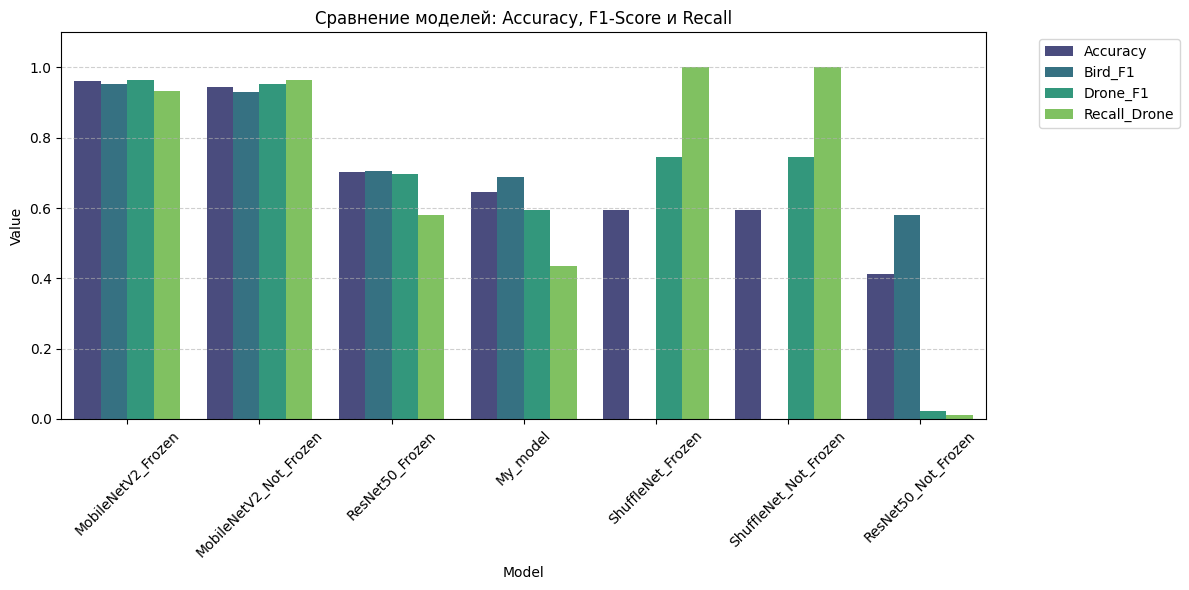

In [63]:
# Переводим таблицу в "длинный" формат для Seaborn
df_plot = df_results.melt(id_vars='Model', var_name='Metric', value_name='Value')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Model', y='Value', hue='Metric', palette='viridis')

plt.title('Сравнение моделей: Accuracy, F1-Score и Recall')
plt.xticks(rotation=45)
plt.ylim(0, 1.1) # Шкала от 0 до 100%
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Сравнение матриц ошибок

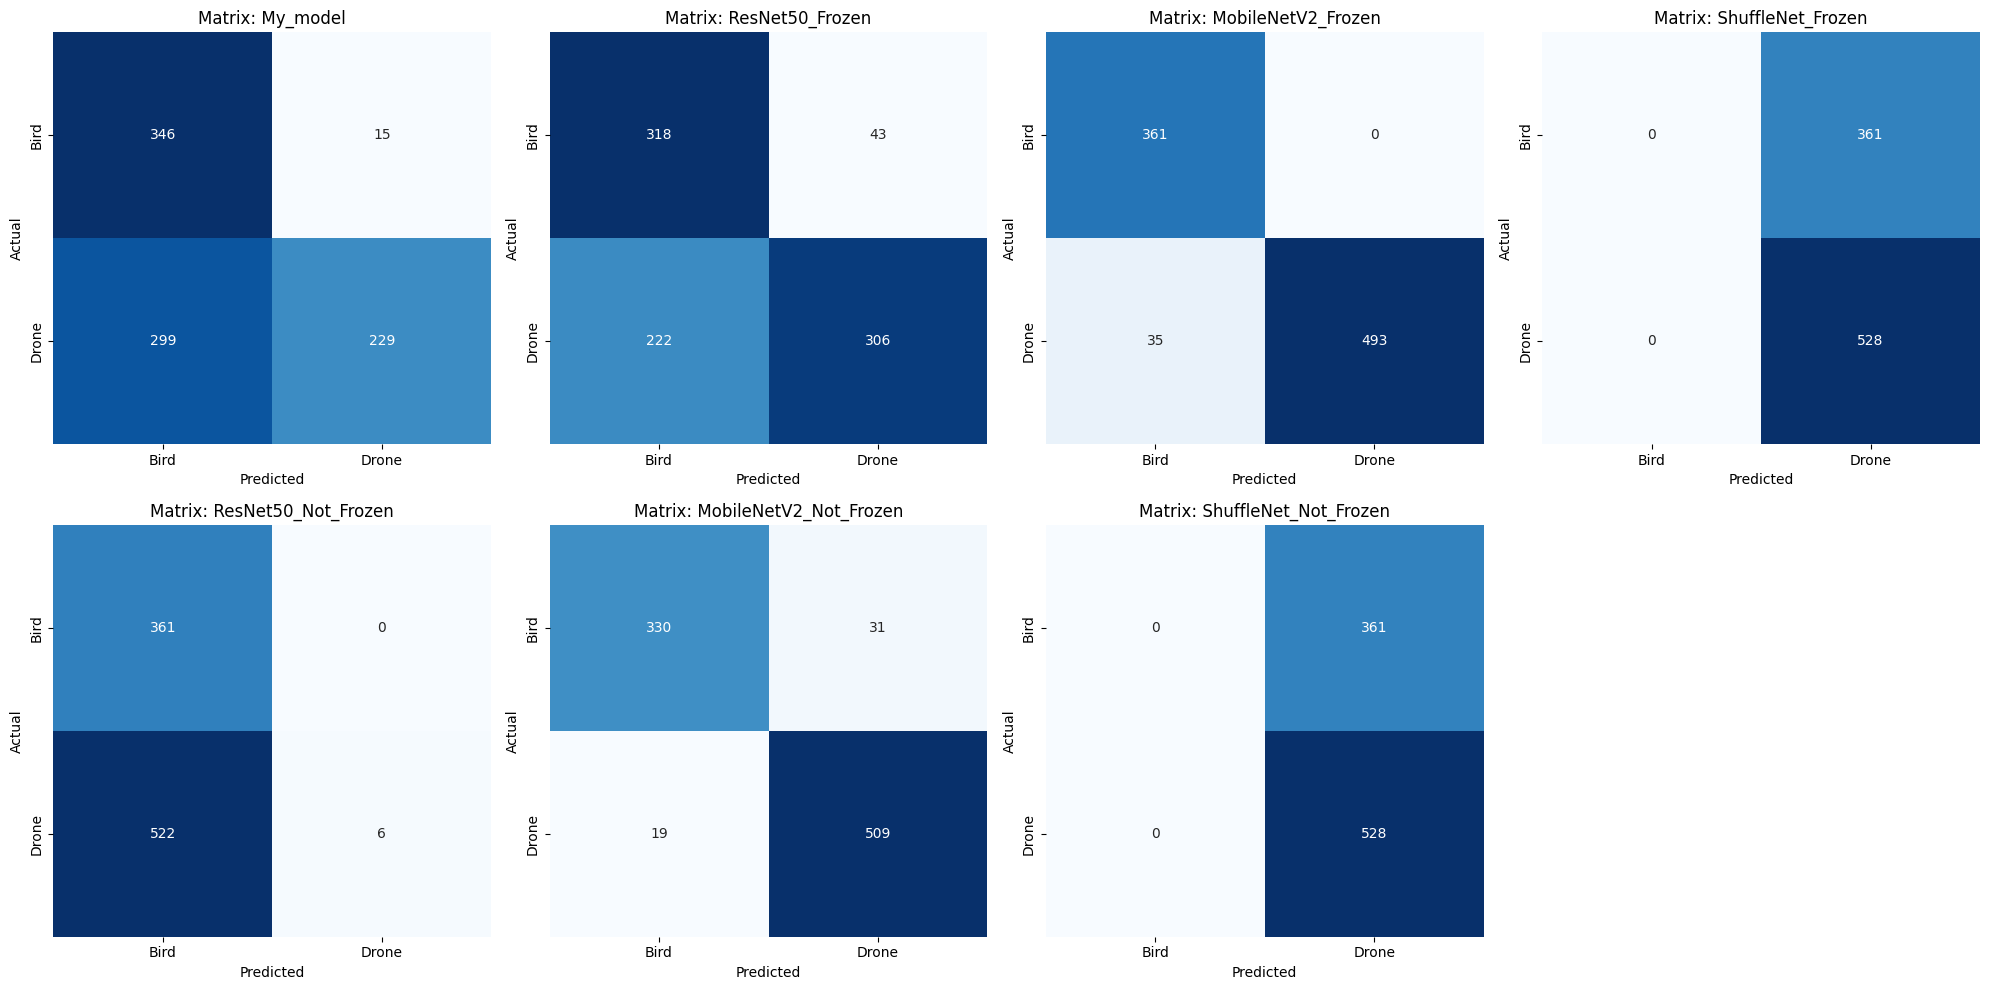

In [65]:
def plot_all_confusion_matrices(cms, names):
    # Создаем сетку 2 строки на 4 колонки. figsize увеличиваем по вертикали до 10.
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten() # Делаем массив осей одномерным для простого цикла

    for i, (cm, name) in enumerate(zip(cms, names)):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
        axes[i].set_title(f'Matrix: {name}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
        axes[i].set_xticklabels(['Bird', 'Drone'])
        axes[i].set_yticklabels(['Bird', 'Drone'])

    # Скрываем пустой 8-й график (так как моделей 7, а ячеек 8)
    if len(cms) < len(axes):
        axes[-1].axis('off')

    plt.tight_layout()
    plt.show()

# Вызов остается без изменений
plot_all_confusion_matrices(
    [model_cm, resnet_cm, mobilenet_cm, shuff_cm, resnet_not_frozen_cm, mobilenet_not_frozen_cm, shuff_not_frozen_cm],
    ['My_model', 'ResNet50_Frozen', 'MobileNetV2_Frozen', 'ShuffleNet_Frozen', 'ResNet50_Not_Frozen', 'MobileNetV2_Not_Frozen', 'ShuffleNet_Not_Frozen']
)